# Unified LiTS dataset preparation and EDA-readiness pipeline

## Goal

Reconcile the three overlapping PNG sources with the authoritative NIfTI CT/segmentation pairs, create one canonical manifest, preview and record required orientation corrections, optionally build a corrected 256×256 staging dataset, and produce EDA-readiness reports and visualizations.

This notebook is deliberately safety-gated:

- Raw source folders are treated as immutable evidence.
- Missing masks are never converted to empty masks.
- The legacy datasets are not concatenated as extra patients.
- The true slice index is parsed from filenames, never from the wrapped CSV `instance_number`.
- Mask transformations are previewed before a build is enabled.
- Promotion and training are outside this notebook.

Run the notebook from top to bottom. The default mode performs audits and previews only.

## 1. Setup and safety controls

Review these paths and switches before running. Keep `BUILD_CORRECTED=False` during the first pass. After reviewing orientation figures, set `TRANSFORM_MAP_APPROVED=True` and `BUILD_CORRECTED=True` to generate a new, isolated staging build.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image
from scipy.ndimage import binary_erosion, label, sobel


PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
PRACTICE_DIR = PROJECT_ROOT / "Practice"
DATASET_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\Dataset")

LITS_MASKS_DIR = DATASET_ROOT / "LiTS_masks"
LITS_PNG_ROOT = DATASET_ROOT / "lits-png"
LITS_PNG_DIR = LITS_PNG_ROOT / "dataset_6" / "dataset_6"
LEGACY_512_DIR = DATASET_ROOT / "Liver Img Dataset"

CANONICAL_ROOT = DATASET_ROOT / "Liver"
NIFTI_VOLUME_DIR = CANONICAL_ROOT / "01_raw_authoritative" / "volumes"
NIFTI_SEGMENTATION_DIR = CANONICAL_ROOT / "01_raw_authoritative" / "segmentations"
CURRENT_BUILD_DIR = CANONICAL_ROOT / "02_staging" / "build_20260713_112738"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
AUDIT_OUTPUT_DIR = PRACTICE_DIR / "unified_dataset_preparation_outputs" / RUN_ID
CORRECTED_BUILD_DIR = CANONICAL_ROOT / "02_staging" / f"build_corrected_{RUN_ID}"

# Safety gates. The first run should keep all three values False.
BUILD_CORRECTED = False
TRANSFORM_MAP_APPROVED = False
COMPUTE_SOURCE_HASHES = True

# Build and preprocessing policy.
EXPECTED_VOLUMES = 131
EXPECTED_SLICES = 58638
OUTPUT_SIZE = (256, 256)
CT_WINDOW_LOW = -160.0
CT_WINDOW_HIGH = 240.0

# Forensic evidence currently recommends a 180-degree in-plane mask correction
# for these volumes. This remains a proposed map until the review cells pass.
PROPOSED_ROT180_VOLUMES = set(range(83, 100)) | set(range(101, 131))
PROPOSED_IDENTITY_VOLUMES = set(range(0, 83)) | {100}

# Review a broad set on the first pass. Change to list(range(131)) for a full
# one-representative-slice orientation diagnostic.
ORIENTATION_REVIEW_VOLUMES = [4, 7, 33, 44, 78, 82, 83, 84, 85, 90, 99, 100, 101, 108, 116, 130]

# Fill only after reviewing the generated overlays. These control the final
# spatial EDA-ready view; they do not modify raw source files.
MANUALLY_APPROVED_VOLUME_IDS: set[int] = set()
MANUALLY_REJECTED_VOLUME_IDS: set[int] = set()

AUDIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "font.size": 10,
})

print(f"audit_output={AUDIT_OUTPUT_DIR}")
print(f"proposed_corrected_build={CORRECTED_BUILD_DIR}")
print(f"BUILD_CORRECTED={BUILD_CORRECTED}")


audit_output=D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\unified_dataset_preparation_outputs\20260724_211625
proposed_corrected_build=D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260724_211625
BUILD_CORRECTED=False


## 2. Shared helpers

These functions standardize key parsing, hashing, image/mask handling, transformations, atomic PNG writing, source profiling and overlay plotting.

In [2]:
KEY_PATTERNS = {
    "lits_masks": re.compile(r"^mask-(\d+)-(\d+)\.png$", re.IGNORECASE),
    "legacy_512": re.compile(r"^Volume-(\d+)-(\d+)\.png$", re.IGNORECASE),
    "lits_png_ct": re.compile(r"^volume-(\d+)_(\d+)\.png$", re.IGNORECASE),
    "lits_png_liver": re.compile(r"^segmentation-(\d+)_livermask_(\d+)\.png$", re.IGNORECASE),
    "lits_png_tumor": re.compile(r"^segmentation-(\d+)_lesionmask_(\d+)\.png$", re.IGNORECASE),
}


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def parse_key(path: Path, source_name: str) -> tuple[int, int]:
    match = KEY_PATTERNS[source_name].match(path.name)
    if not match:
        raise ValueError(f"Unexpected {source_name} filename: {path.name}")
    return int(match.group(1)), int(match.group(2))


def index_png_source(paths, source_name: str, path_column: str) -> pd.DataFrame:
    rows = []
    for path in paths:
        volume_id, slice_index = parse_key(path, source_name)
        rows.append({"volume_id": volume_id, "slice_index": slice_index, path_column: str(path)})
    frame = pd.DataFrame(rows)
    if frame.empty:
        return pd.DataFrame(columns=["volume_id", "slice_index", path_column])
    if frame.duplicated(["volume_id", "slice_index"]).any():
        duplicates = frame[frame.duplicated(["volume_id", "slice_index"], keep=False)]
        raise RuntimeError(f"Duplicate keys in {source_name}:\n{duplicates.head()}")
    return frame.sort_values(["volume_id", "slice_index"]).reset_index(drop=True)


def read_gray(path: Path, size: tuple[int, int] | None = None, nearest: bool = False) -> np.ndarray:
    with Image.open(path) as image:
        image = image.convert("L")
        if size is not None and image.size != size:
            method = Image.Resampling.NEAREST if nearest else Image.Resampling.BILINEAR
            image = image.resize(size, method)
        return np.asarray(image).copy()


def resize_array(array: np.ndarray, size=(256, 256), nearest: bool = False) -> np.ndarray:
    method = Image.Resampling.NEAREST if nearest else Image.Resampling.BILINEAR
    return np.asarray(Image.fromarray(array).resize(size, method))


def window_ct(array: np.ndarray) -> np.ndarray:
    clipped = np.clip(array.astype(np.float32), CT_WINDOW_LOW, CT_WINDOW_HIGH)
    scaled = (clipped - CT_WINDOW_LOW) / (CT_WINDOW_HIGH - CT_WINDOW_LOW)
    return np.rint(scaled * 255.0).astype(np.uint8)


def apply_transform(array: np.ndarray, transform_name: str) -> np.ndarray:
    if transform_name == "identity":
        return array
    if transform_name == "rot180":
        return np.rot90(array, 2)
    if transform_name == "flip_lr":
        return np.fliplr(array)
    if transform_name == "flip_ud":
        return np.flipud(array)
    raise ValueError(f"Unsupported transform: {transform_name}")


def proposed_transform(volume_id: int) -> str:
    if volume_id in PROPOSED_ROT180_VOLUMES:
        return "rot180"
    if volume_id in PROPOSED_IDENTITY_VOLUMES:
        return "identity"
    raise KeyError(f"Volume {volume_id} is not covered by the proposed transform map")


def save_png_atomic(array: np.ndarray, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(".tmp.png")
    Image.fromarray(array).save(temporary)
    temporary.replace(destination)


def mask_dice(left: np.ndarray, right: np.ndarray) -> float:
    a = left > 0
    b = right > 0
    denominator = int(a.sum() + b.sum())
    return float(2 * np.logical_and(a, b).sum() / denominator) if denominator else 1.0


def boundary_gradient(image: np.ndarray, mask: np.ndarray) -> float:
    mask = mask.astype(bool)
    if not mask.any():
        return float("nan")
    gradient = np.hypot(sobel(image.astype(np.float32), axis=0), sobel(image.astype(np.float32), axis=1))
    boundary = np.logical_xor(mask, binary_erosion(mask))
    return float(gradient[boundary].mean()) if boundary.any() else float("nan")


def plot_overlay(ax, image: np.ndarray, organ: np.ndarray, tumor: np.ndarray, title: str) -> None:
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    if np.any(organ):
        ax.contour(organ.astype(float), levels=[0.5], colors=["#22c55e"], linewidths=1.0)
    if np.any(tumor):
        ax.contour(tumor.astype(float), levels=[0.5], colors=["#ef4444"], linewidths=1.0)
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def write_json(data, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")


## 3. Inventory the three PNG sources

The output is one source record per `(volume_id, slice_index)`. The three folders are not concatenated; they are joined as alternative representations of the same canonical key.

In [3]:
required_directories = [LITS_MASKS_DIR, LITS_PNG_DIR, LEGACY_512_DIR, NIFTI_VOLUME_DIR, NIFTI_SEGMENTATION_DIR]
missing_directories = [str(path) for path in required_directories if not path.is_dir()]
if missing_directories:
    raise FileNotFoundError(f"Missing required directories: {missing_directories}")

lits_masks_index = index_png_source(LITS_MASKS_DIR.glob("mask-*.png"), "lits_masks", "lits_masks_path")
legacy_512_index = index_png_source(LEGACY_512_DIR.glob("Volume-*.png"), "legacy_512", "legacy_512_path")
lits_png_ct_index = index_png_source(LITS_PNG_DIR.glob("volume-*.png"), "lits_png_ct", "lits_png_ct_path")
lits_png_liver_index = index_png_source(LITS_PNG_DIR.glob("segmentation-*_livermask_*.png"), "lits_png_liver", "lits_png_liver_path")
lits_png_tumor_index = index_png_source(LITS_PNG_DIR.glob("segmentation-*_lesionmask_*.png"), "lits_png_tumor", "lits_png_tumor_path")

source_frames = {
    "LiTS_masks tumor masks": lits_masks_index,
    "lits-png CT": lits_png_ct_index,
    "lits-png liver masks": lits_png_liver_index,
    "lits-png tumor masks": lits_png_tumor_index,
    "legacy 512 CT": legacy_512_index,
}

source_inventory = []
for source_name, frame in source_frames.items():
    source_inventory.append({
        "source": source_name,
        "rows": len(frame),
        "volumes": int(frame.volume_id.nunique()) if len(frame) else 0,
        "duplicate_keys": int(frame.duplicated(["volume_id", "slice_index"]).sum()) if len(frame) else 0,
    })

source_inventory_df = pd.DataFrame(source_inventory)
source_inventory_df.to_csv(AUDIT_OUTPUT_DIR / "source_inventory.csv", index=False)
display(source_inventory_df)


,source,rows,volumes,duplicate_keys
0,LiTS_masks tumor masks,58638,131,0
1,lits-png CT,58638,131,0
2,lits-png liver masks,15868,25,0
3,lits-png tumor masks,15817,25,0
4,legacy 512 CT,58638,131,0


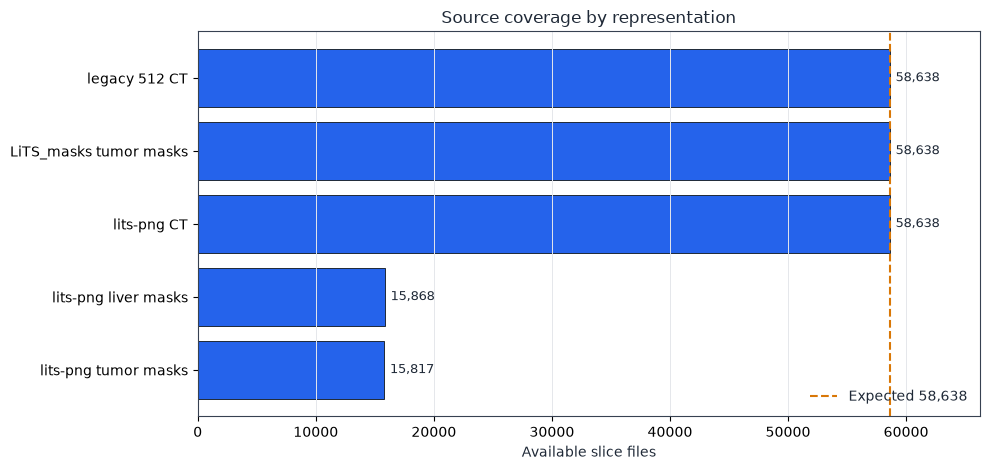

In [4]:
# Source coverage visual: exact counts, not inferred completeness.
fig, ax = plt.subplots(figsize=(10, 4.8))
ordered = source_inventory_df.sort_values("rows")
bars = ax.barh(ordered.source, ordered.rows, color="#2563eb", edgecolor="#1f2937", linewidth=0.7)
ax.axvline(EXPECTED_SLICES, color="#d97706", linestyle="--", linewidth=1.5, label=f"Expected {EXPECTED_SLICES:,}")
ax.bar_label(bars, labels=[f"{value:,}" for value in ordered.rows], padding=4, fontsize=9)
ax.set_xlim(0, EXPECTED_SLICES * 1.13)
ax.set_xlabel("Available slice files")
ax.set_title("Source coverage by representation")
ax.grid(axis="x", color="#e5e7eb", linewidth=0.7)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


## 4. Build the cross-source slice registry

This table exposes missing files explicitly. A missing mask remains missing; it is never silently replaced with a zero mask.

In [5]:
crosswalk = lits_masks_index.copy()
for frame in [lits_png_ct_index, lits_png_liver_index, lits_png_tumor_index, legacy_512_index]:
    crosswalk = crosswalk.merge(frame, on=["volume_id", "slice_index"], how="outer", validate="one_to_one")

path_columns = [
    "lits_masks_path", "lits_png_ct_path", "lits_png_liver_path",
    "lits_png_tumor_path", "legacy_512_path",
]
for column in path_columns:
    crosswalk[f"{column}_available"] = crosswalk[column].notna()

crosswalk["sample_id"] = crosswalk.apply(
    lambda row: f"v{int(row.volume_id):03d}_s{int(row.slice_index):04d}", axis=1
)
crosswalk = crosswalk.sort_values(["volume_id", "slice_index"]).reset_index(drop=True)

if crosswalk.duplicated(["volume_id", "slice_index"]).any():
    raise RuntimeError("Cross-source registry contains duplicate canonical keys")

crosswalk.to_csv(AUDIT_OUTPUT_DIR / "source_crosswalk.csv", index=False)
print(f"canonical_keys={len(crosswalk):,}")
print(f"volumes={crosswalk.volume_id.nunique()}")
display(crosswalk.head())


canonical_keys=58,638
volumes=131


,volume_id,slice_index,lits_masks_path,lits_png_ct_path,lits_png_liver_path,lits_png_tumor_path,legacy_512_path,lits_masks_path_available,lits_png_ct_path_available,lits_png_liver_path_available,lits_png_tumor_path_available,legacy_512_path_available,sample_id
0,0,0,D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_mas...,D:\DATA SCIENCE AND ANALYTICS\Dataset\lits-png...,NaN,NaN,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Im...,True,True,False,False,True,v000_s0000
1,0,1,D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_mas...,D:\DATA SCIENCE AND ANALYTICS\Dataset\lits-png...,NaN,NaN,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Im...,True,True,False,False,True,v000_s0001
2,0,2,D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_mas...,D:\DATA SCIENCE AND ANALYTICS\Dataset\lits-png...,NaN,NaN,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Im...,True,True,False,False,True,v000_s0002
3,0,3,D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_mas...,D:\DATA SCIENCE AND ANALYTICS\Dataset\lits-png...,NaN,NaN,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Im...,True,True,False,False,True,v000_s0003
4,0,4,D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_mas...,D:\DATA SCIENCE AND ANALYTICS\Dataset\lits-png...,NaN,NaN,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Im...,True,True,False,False,True,v000_s0004


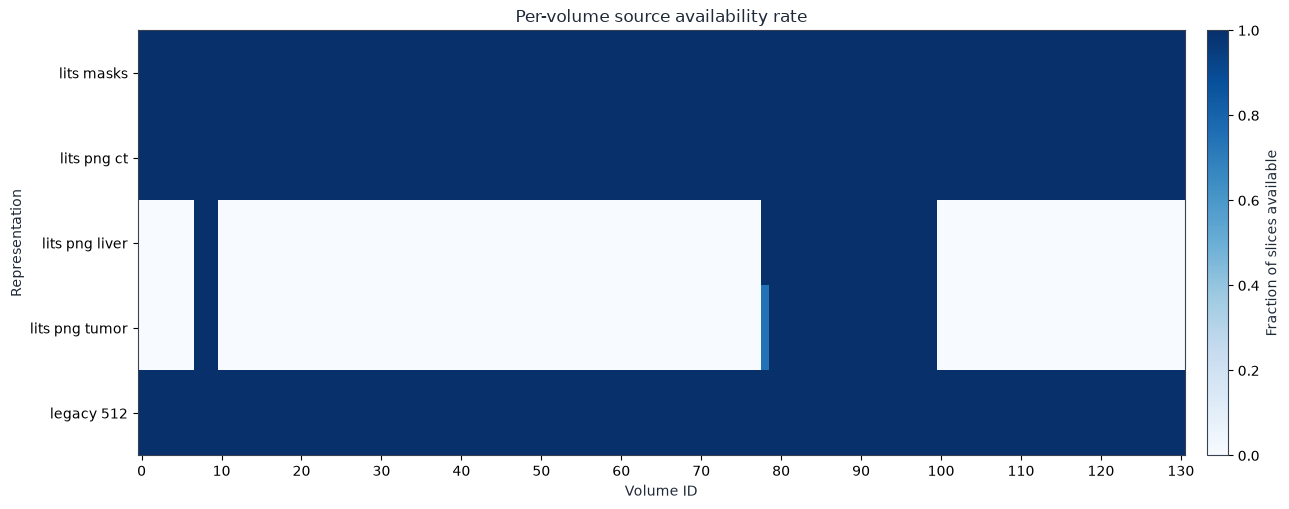

In [6]:
# Per-volume source availability heatmap.
availability_columns = [f"{column}_available" for column in path_columns]
availability_by_volume = crosswalk.groupby("volume_id")[availability_columns].mean()

fig, ax = plt.subplots(figsize=(13, 5.2))
matrix = availability_by_volume.T.to_numpy()
image = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_yticks(range(len(availability_columns)))
ax.set_yticklabels([name.replace("_path_available", "").replace("_", " ") for name in availability_columns])
ax.set_xlabel("Volume ID")
ax.set_ylabel("Representation")
ax.set_title("Per-volume source availability rate")
tick_positions = list(range(0, EXPECTED_VOLUMES, 10))
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_positions)
colorbar = fig.colorbar(image, ax=ax, fraction=0.02, pad=0.02)
colorbar.set_label("Fraction of slices available")
plt.tight_layout()
plt.show()


## 5. Audit the historical CSV files

The notebook derives `slice_index` from the filepath suffix and renames the misleading `*_mask_empty` fields to `*_present_legacy`.

In [7]:
csv_path = LITS_PNG_ROOT / "lits_df.csv"
legacy_csv = pd.read_csv(csv_path)
legacy_csv["slice_index_from_path"] = legacy_csv.filepath.str.extract(r"_(\d+)\.png$")[0].astype(int)
legacy_csv["volume_id_from_path"] = legacy_csv.filepath.str.extract(r"volume-(\d+)_")[0].astype(int)
legacy_csv["liver_present_legacy"] = legacy_csv["liver_mask_empty"].astype(bool)
legacy_csv["tumor_present_legacy"] = legacy_csv["tumor_mask_empty"].astype(bool)

csv_audit = {
    "rows": len(legacy_csv),
    "unique_filepath_keys": int(legacy_csv[["volume_id_from_path", "slice_index_from_path"]].drop_duplicates().shape[0]),
    "wrapped_instance_rows": int((legacy_csv.instance_number != legacy_csv.slice_index_from_path).sum()),
    "instance_mod256_matches": int(((legacy_csv.slice_index_from_path % 256) == legacy_csv.instance_number).sum()),
    "liver_present_rows": int(legacy_csv.liver_present_legacy.sum()),
    "tumor_present_rows": int(legacy_csv.tumor_present_legacy.sum()),
}
write_json(csv_audit, AUDIT_OUTPUT_DIR / "legacy_csv_audit.json")
display(pd.DataFrame([csv_audit]))

if csv_audit["unique_filepath_keys"] != EXPECTED_SLICES:
    raise RuntimeError("The legacy CSV does not provide the expected unique filepath-derived keys")


,rows,unique_filepath_keys,wrapped_instance_rows,instance_mod256_matches,liver_present_rows,tumor_present_rows
0,58638,58638,30105,58638,19143,7114


## 6. Validate authoritative NIfTI pairs

This stage checks pair completeness, shapes, axis codes and affine agreement. Affine disagreement is recorded—not ignored—and later orientation correction is evaluated against overlays and cross-source evidence.

In [8]:
def nifti_path_map(directory: Path, prefix: str) -> dict[int, Path]:
    mapping = {}
    pattern = re.compile(rf"^{re.escape(prefix)}-(\d+)\.nii(?:\.gz)?$", re.IGNORECASE)
    for path in directory.glob(f"{prefix}-*.nii*"):
        match = pattern.match(path.name)
        if match:
            volume_id = int(match.group(1))
            if volume_id in mapping:
                raise RuntimeError(f"Duplicate NIfTI {prefix} for volume {volume_id}")
            mapping[volume_id] = path
    return mapping


volume_paths = nifti_path_map(NIFTI_VOLUME_DIR, "volume")
segmentation_paths = nifti_path_map(NIFTI_SEGMENTATION_DIR, "segmentation")
all_nifti_ids = sorted(set(volume_paths) | set(segmentation_paths))

volume_registry_rows = []
for volume_id in all_nifti_ids:
    volume_path = volume_paths.get(volume_id)
    segmentation_path = segmentation_paths.get(volume_id)
    row = {
        "volume_id": volume_id,
        "volume_path": str(volume_path) if volume_path else None,
        "segmentation_path": str(segmentation_path) if segmentation_path else None,
        "pair_complete": bool(volume_path and segmentation_path),
    }
    if volume_path and segmentation_path:
        ct_image = nib.load(str(volume_path))
        seg_image = nib.load(str(segmentation_path))
        row.update({
            "ct_shape": str(ct_image.shape),
            "seg_shape": str(seg_image.shape),
            "shape_match": ct_image.shape == seg_image.shape,
            "ct_axis_codes": str(nib.aff2axcodes(ct_image.affine)),
            "seg_axis_codes": str(nib.aff2axcodes(seg_image.affine)),
            "affine_match": bool(np.allclose(ct_image.affine, seg_image.affine, atol=1e-4)),
            "ct_spacing": str(tuple(float(v) for v in ct_image.header.get_zooms()[:3])),
            "seg_spacing": str(tuple(float(v) for v in seg_image.header.get_zooms()[:3])),
            "slice_count": int(ct_image.shape[2]),
        })
    volume_registry_rows.append(row)

volume_registry = pd.DataFrame(volume_registry_rows).sort_values("volume_id")
volume_registry.to_csv(AUDIT_OUTPUT_DIR / "volume_source_registry.csv", index=False)

nifti_summary = {
    "complete_pairs": int(volume_registry.pair_complete.sum()),
    "shape_matches": int(volume_registry.shape_match.fillna(False).sum()),
    "affine_matches": int(volume_registry.affine_match.fillna(False).sum()),
    "total_slices": int(volume_registry.slice_count.fillna(0).sum()),
}
write_json(nifti_summary, AUDIT_OUTPUT_DIR / "nifti_pair_summary.json")
display(pd.DataFrame([nifti_summary]))


,complete_pairs,shape_matches,affine_matches,total_slices
0,131,131,79,58638


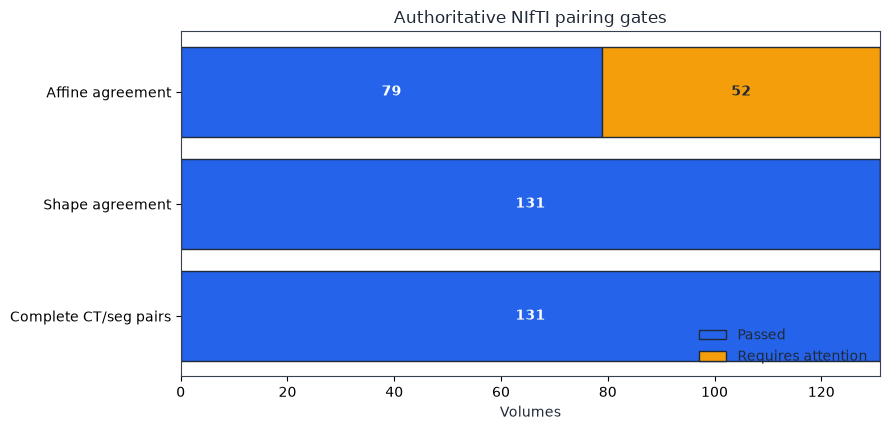

In [9]:
# Volume-pair status visual.
pair_metrics = pd.DataFrame({
    "gate": ["Complete CT/seg pairs", "Shape agreement", "Affine agreement"],
    "passed": [
        int(volume_registry.pair_complete.sum()),
        int(volume_registry.shape_match.fillna(False).sum()),
        int(volume_registry.affine_match.fillna(False).sum()),
    ],
})
pair_metrics["failed"] = EXPECTED_VOLUMES - pair_metrics.passed

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(pair_metrics.gate, pair_metrics.passed, color="#2563eb", edgecolor="#1f2937", label="Passed")
ax.barh(pair_metrics.gate, pair_metrics.failed, left=pair_metrics.passed, color="#f59e0b", edgecolor="#1f2937", label="Requires attention")
for y, row in pair_metrics.iterrows():
    ax.text(row.passed / 2, y, f"{row.passed}", ha="center", va="center", color="white", fontweight="bold")
    if row.failed:
        ax.text(row.passed + row.failed / 2, y, f"{row.failed}", ha="center", va="center", color="#1f2937", fontweight="bold")
ax.set_xlim(0, EXPECTED_VOLUMES)
ax.set_xlabel("Volumes")
ax.set_title("Authoritative NIfTI pairing gates")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


## 7. Orientation diagnostics and correction preview

For each selected volume, the notebook compares the organ boundary gradient for the identity and proposed correction. This score is supporting evidence only. The overlay review remains mandatory.

Green = organ; red = tumor.

In [10]:
current_manifest_path = CURRENT_BUILD_DIR / "manifests" / "slice_manifest.csv"
if not current_manifest_path.exists():
    raise FileNotFoundError(f"Representative-slice manifest not found: {current_manifest_path}")

current_manifest = pd.read_csv(current_manifest_path)


def representative_slice(volume_id: int) -> int:
    group = current_manifest[current_manifest.volume_id == volume_id]
    if group.empty:
        raise KeyError(f"Volume {volume_id} is missing from the current manifest")
    ordered = group.sort_values(["tumor_pixels_256", "organ_pixels_256"], ascending=False)
    return int(ordered.iloc[0].slice_index)


def load_nifti_slice(volume_id: int, slice_index: int) -> tuple[np.ndarray, np.ndarray]:
    ct_image = nib.load(str(volume_paths[volume_id]))
    seg_image = nib.load(str(segmentation_paths[volume_id]))
    ct_slice = np.asanyarray(ct_image.dataobj[:, :, slice_index]).astype(np.float32)
    seg_slice = np.asanyarray(seg_image.dataobj[:, :, slice_index])
    return ct_slice, seg_slice


orientation_rows = []
for volume_id in ORIENTATION_REVIEW_VOLUMES:
    slice_index = representative_slice(volume_id)
    ct_slice, seg_slice = load_nifti_slice(volume_id, slice_index)
    image_256 = resize_array(window_ct(ct_slice), OUTPUT_SIZE, nearest=False)

    for candidate in ["identity", "rot180"]:
        organ_base = resize_array((seg_slice > 0).astype(np.uint8), OUTPUT_SIZE, nearest=True) > 0
        tumor_base = resize_array((seg_slice == 2).astype(np.uint8), OUTPUT_SIZE, nearest=True) > 0
        organ_256 = apply_transform(organ_base, candidate)
        tumor_256 = apply_transform(tumor_base, candidate)
        orientation_rows.append({
            "volume_id": volume_id,
            "slice_index": slice_index,
            "candidate": candidate,
            "proposed": candidate == proposed_transform(volume_id),
            "organ_pixels": int(organ_256.sum()),
            "tumor_pixels": int(tumor_256.sum()),
            "boundary_gradient": boundary_gradient(image_256, organ_256),
            "tumor_inside_organ": bool(np.all(~tumor_256 | organ_256)),
        })

orientation_diagnostics = pd.DataFrame(orientation_rows)
orientation_diagnostics.to_csv(AUDIT_OUTPUT_DIR / "orientation_diagnostics.csv", index=False)
display(orientation_diagnostics.head(8))


,volume_id,slice_index,candidate,proposed,organ_pixels,tumor_pixels,boundary_gradient,tumor_inside_organ
0,4,464,identity,True,7181,3640,163.339386,True
1,4,464,rot180,False,7181,3640,154.967957,True
2,7,373,identity,True,2772,283,263.991760,True
3,7,373,rot180,False,2772,283,146.617416,True
4,33,100,identity,True,8574,3127,208.300278,True
5,33,100,rot180,False,8574,3127,163.280151,True
6,44,97,identity,True,7343,2411,222.459305,True
7,44,97,rot180,False,7343,2411,110.680939,True


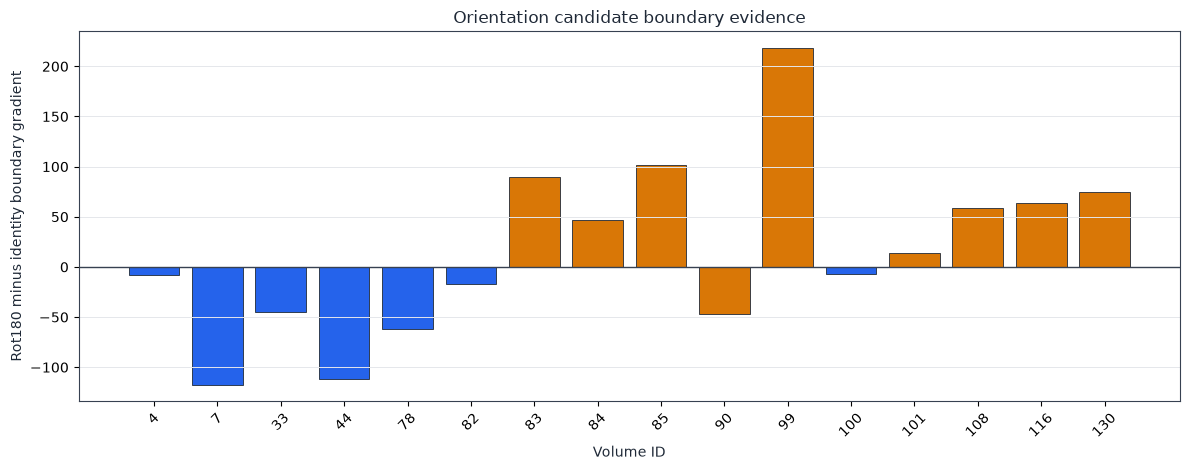

In [11]:
# Boundary-gradient comparison; larger is supportive but not decisive.
orientation_pivot = orientation_diagnostics.pivot(index="volume_id", columns="candidate", values="boundary_gradient")
orientation_pivot["rot180_minus_identity"] = orientation_pivot.rot180 - orientation_pivot.identity

fig, ax = plt.subplots(figsize=(12, 4.8))
colors = ["#d97706" if volume_id in PROPOSED_ROT180_VOLUMES else "#2563eb" for volume_id in orientation_pivot.index]
ax.bar(orientation_pivot.index.astype(str), orientation_pivot.rot180_minus_identity, color=colors, edgecolor="#1f2937", linewidth=0.6)
ax.axhline(0, color="#374151", linewidth=1)
ax.set_xlabel("Volume ID")
ax.set_ylabel("Rot180 minus identity boundary gradient")
ax.set_title("Orientation candidate boundary evidence")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", color="#e5e7eb", linewidth=0.7)
plt.tight_layout()
plt.show()


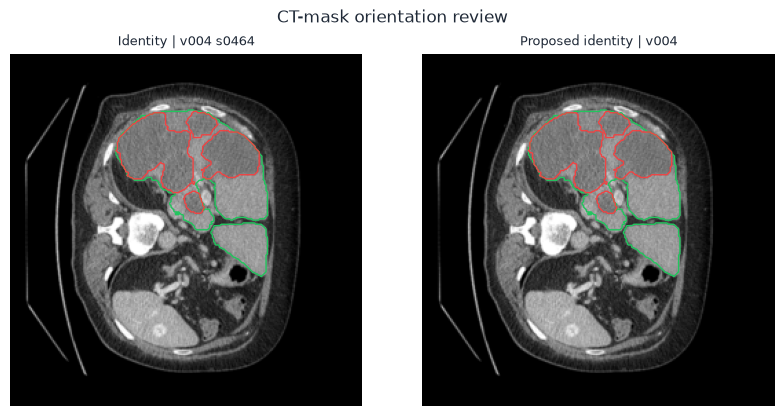

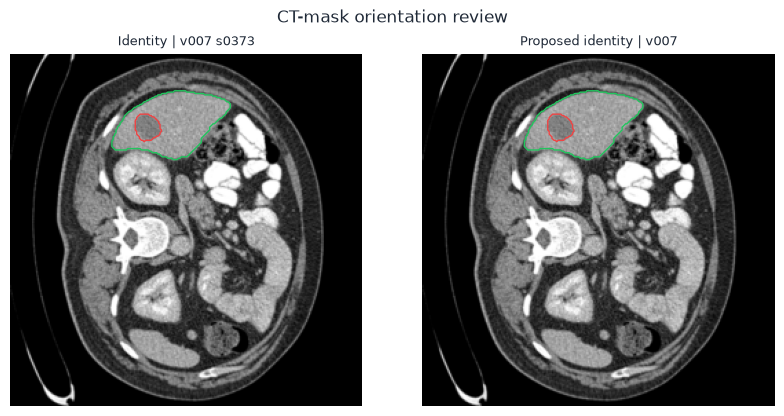

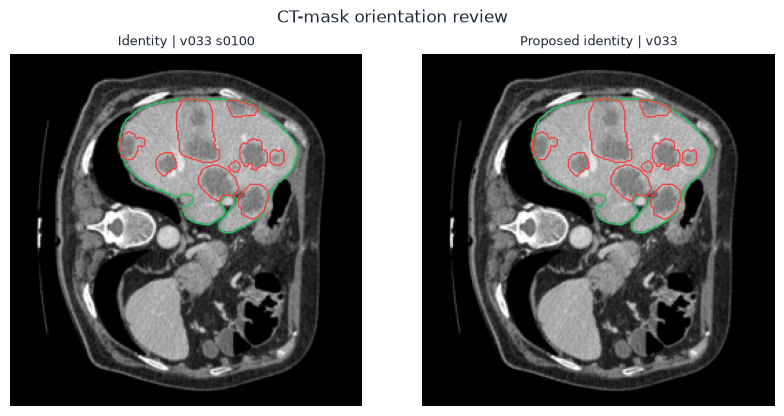

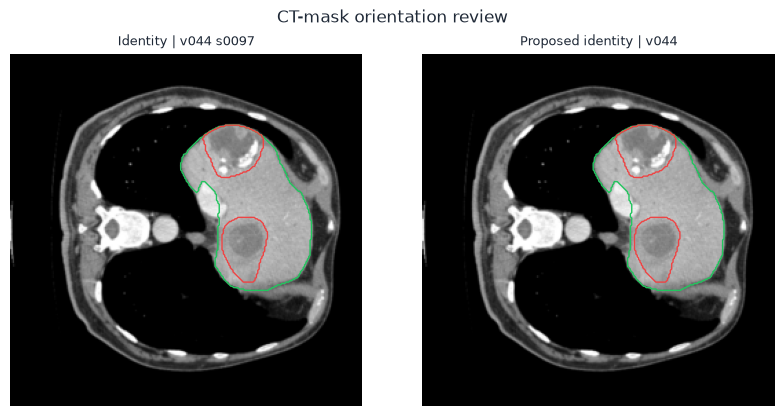

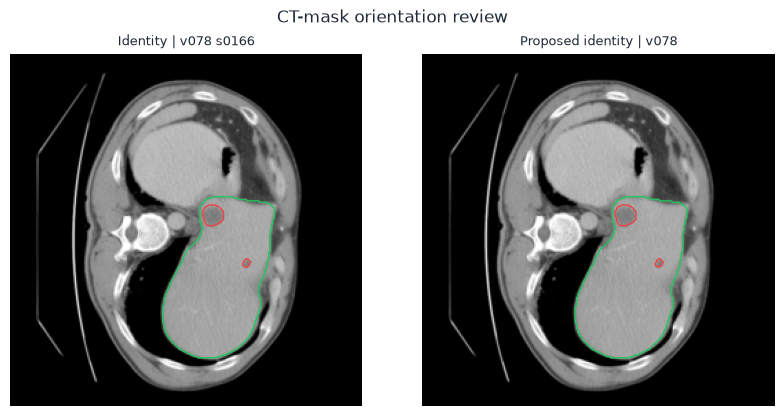

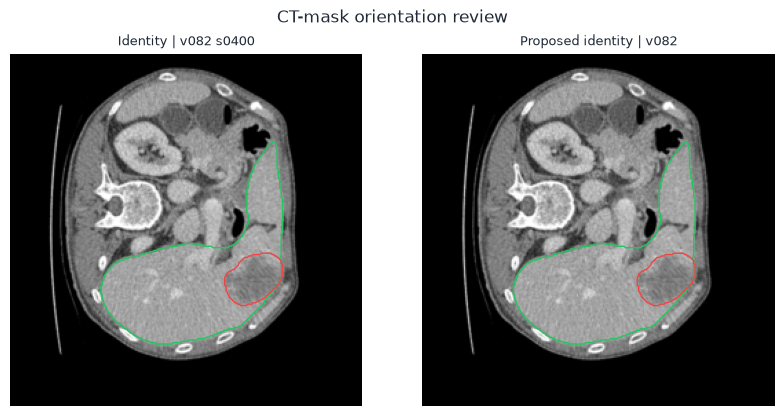

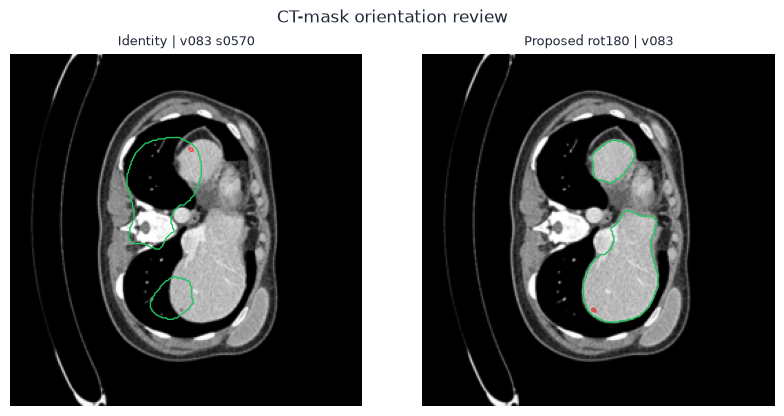

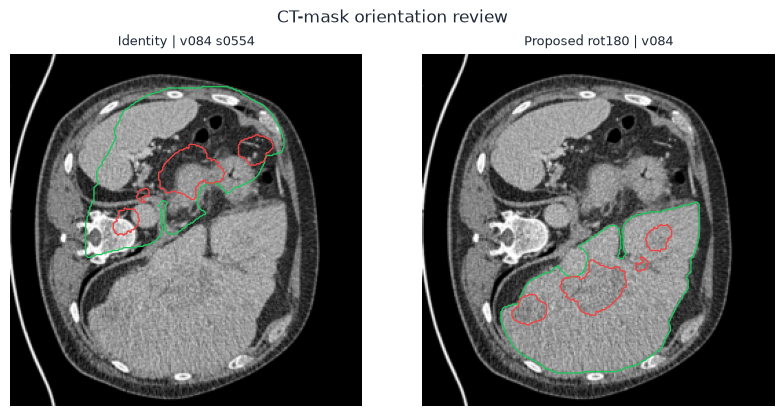

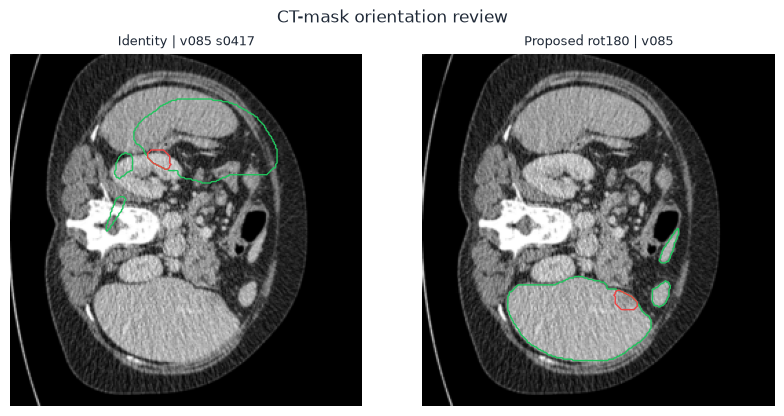

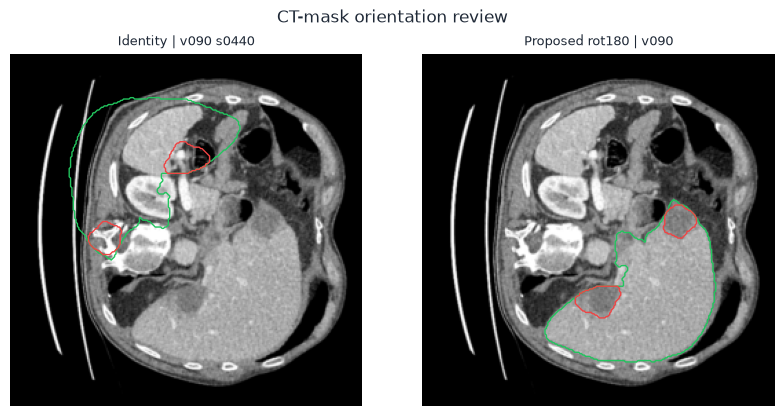

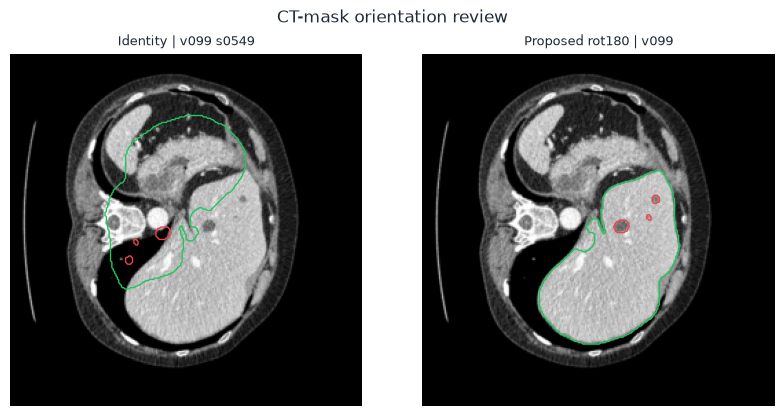

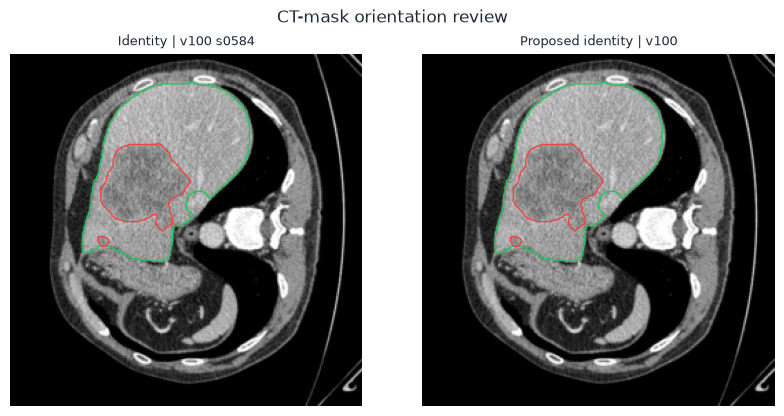

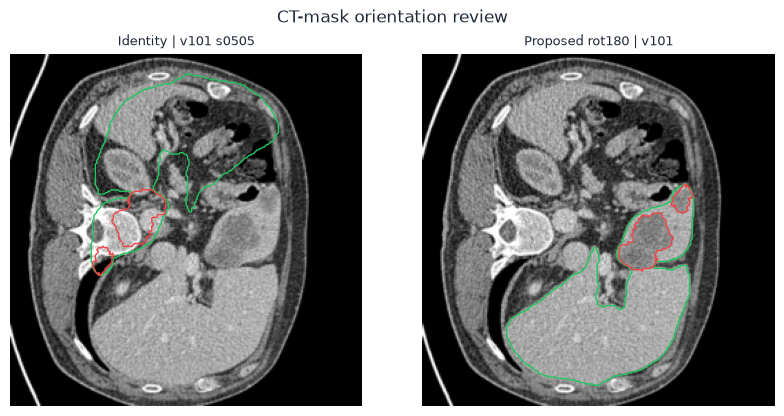

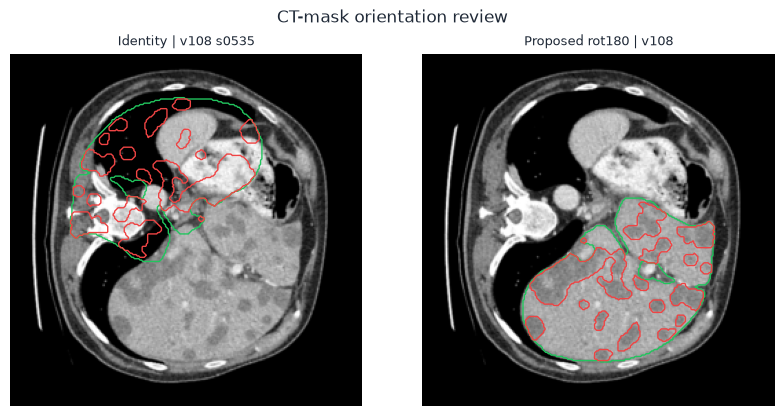

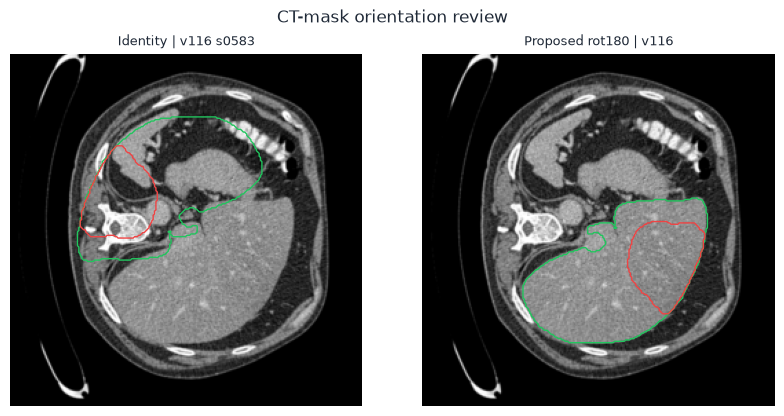

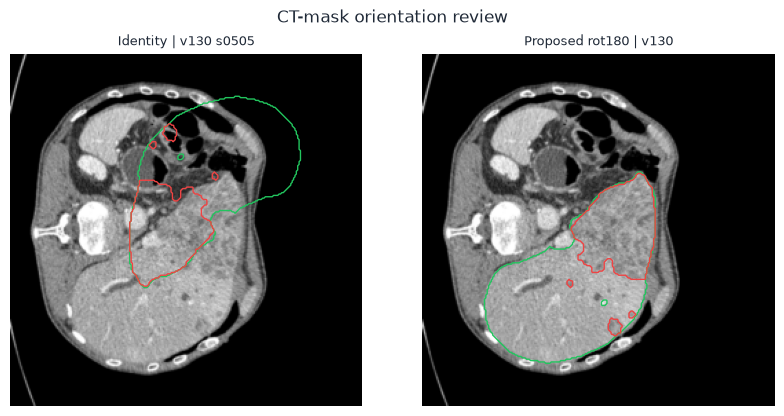

review_figures=D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\unified_dataset_preparation_outputs\20260724_211625\orientation_reviews


In [12]:
# Before/after overlays for every selected review volume.
figure_dir = AUDIT_OUTPUT_DIR / "orientation_reviews"
figure_dir.mkdir(parents=True, exist_ok=True)

for volume_id in ORIENTATION_REVIEW_VOLUMES:
    slice_index = representative_slice(volume_id)
    ct_slice, seg_slice = load_nifti_slice(volume_id, slice_index)
    image_256 = resize_array(window_ct(ct_slice), OUTPUT_SIZE, nearest=False)

    proposed_name = proposed_transform(volume_id)
    identity_organ = resize_array((seg_slice > 0).astype(np.uint8), OUTPUT_SIZE, nearest=True) > 0
    identity_tumor = resize_array((seg_slice == 2).astype(np.uint8), OUTPUT_SIZE, nearest=True) > 0
    corrected_organ = apply_transform(identity_organ, proposed_name)
    corrected_tumor = apply_transform(identity_tumor, proposed_name)

    fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2))
    plot_overlay(axes[0], image_256, identity_organ, identity_tumor, f"Identity | v{volume_id:03d} s{slice_index:04d}")
    plot_overlay(axes[1], image_256, corrected_organ, corrected_tumor, f"Proposed {proposed_name} | v{volume_id:03d}")
    fig.suptitle("CT-mask orientation review", fontsize=12)
    plt.tight_layout()
    output_path = figure_dir / f"v{volume_id:03d}_s{slice_index:04d}_orientation_review.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"review_figures={figure_dir}")


## 8. Optional corrected staging build

This is the only data-writing stage. It writes a new timestamped directory and never overwrites the raw datasets or the previous build.

Before enabling it:

1. Review the generated orientation figures.
2. Confirm every volume is covered by exactly one transform.
3. Set `TRANSFORM_MAP_APPROVED=True`.
4. Set `BUILD_CORRECTED=True`.
5. Restart the kernel and run from the top.

In [13]:
def build_corrected_staging(output_dir: Path) -> pd.DataFrame:
    if output_dir.exists() and any(output_dir.iterdir()):
        raise FileExistsError(f"Refusing to overwrite nonempty build directory: {output_dir}")
    if not TRANSFORM_MAP_APPROVED:
        raise RuntimeError("Set TRANSFORM_MAP_APPROVED=True only after reviewing orientation evidence")
    if PROPOSED_IDENTITY_VOLUMES & PROPOSED_ROT180_VOLUMES:
        raise RuntimeError("Transform-map volume sets overlap")
    if PROPOSED_IDENTITY_VOLUMES | PROPOSED_ROT180_VOLUMES != set(range(EXPECTED_VOLUMES)):
        raise RuntimeError("Transform map does not cover exactly volumes 0-130")

    manifest_rows = []
    source_hash_cache = {}

    for volume_id in range(EXPECTED_VOLUMES):
        ct_path = volume_paths[volume_id]
        seg_path = segmentation_paths[volume_id]
        ct_image = nib.load(str(ct_path))
        seg_image = nib.load(str(seg_path))
        if ct_image.shape != seg_image.shape:
            raise RuntimeError(f"Shape mismatch for volume {volume_id}: {ct_image.shape} vs {seg_image.shape}")

        if COMPUTE_SOURCE_HASHES:
            source_hash_cache[(volume_id, "ct")] = sha256_file(ct_path)
            source_hash_cache[(volume_id, "seg")] = sha256_file(seg_path)

        transform_name = proposed_transform(volume_id)
        for slice_index in range(ct_image.shape[2]):
            ct_slice = np.asanyarray(ct_image.dataobj[:, :, slice_index]).astype(np.float32)
            seg_slice = np.asanyarray(seg_image.dataobj[:, :, slice_index])
            labels = set(np.unique(seg_slice).astype(int).tolist())
            if not labels.issubset({0, 1, 2}):
                raise RuntimeError(f"Invalid labels {labels} in volume {volume_id}, slice {slice_index}")

            image_256 = resize_array(window_ct(ct_slice), OUTPUT_SIZE, nearest=False).astype(np.uint8)
            organ_256 = resize_array((seg_slice > 0).astype(np.uint8) * 255, OUTPUT_SIZE, nearest=True).astype(np.uint8)
            tumor_256 = resize_array((seg_slice == 2).astype(np.uint8) * 255, OUTPUT_SIZE, nearest=True).astype(np.uint8)
            organ_256 = apply_transform(organ_256, transform_name).copy()
            tumor_256 = apply_transform(tumor_256, transform_name).copy()

            organ_binary = organ_256 > 0
            tumor_binary = tumor_256 > 0
            if np.any(tumor_binary & ~organ_binary):
                raise RuntimeError(f"Tumor outside organ for volume {volume_id}, slice {slice_index}")

            image_rel = Path("images") / f"v{volume_id:03d}" / f"s{slice_index:04d}.png"
            organ_rel = Path("organ_masks") / f"v{volume_id:03d}" / f"s{slice_index:04d}.png"
            tumor_rel = Path("tumor_masks") / f"v{volume_id:03d}" / f"s{slice_index:04d}.png"
            save_png_atomic(image_256, output_dir / image_rel)
            save_png_atomic(organ_256, output_dir / organ_rel)
            save_png_atomic(tumor_256, output_dir / tumor_rel)

            manifest_rows.append({
                "sample_id": f"v{volume_id:03d}_s{slice_index:04d}",
                "volume_id": volume_id,
                "slice_index": slice_index,
                "image_path": str(image_rel),
                "organ_mask_path": str(organ_rel),
                "tumor_mask_path": str(tumor_rel),
                "source_volume_path": str(ct_path),
                "source_segmentation_path": str(seg_path),
                "source_volume_sha256": source_hash_cache.get((volume_id, "ct")),
                "source_segmentation_sha256": source_hash_cache.get((volume_id, "seg")),
                "transform_applied": transform_name,
                "image_width": OUTPUT_SIZE[0],
                "image_height": OUTPUT_SIZE[1],
                "organ_pixels": int(organ_binary.sum()),
                "tumor_pixels": int(tumor_binary.sum()),
                "organ_present": bool(organ_binary.any()),
                "tumor_present": bool(tumor_binary.any()),
                "automatic_integrity_pass": True,
                "verification_status": "pending_spatial_review",
                "exclusion_reason": None,
                "build_id": output_dir.name,
                "preprocessing_profile": "HU[-160,240]_bilinear_image_nearest_mask_256",
            })

        print(f"built volume {volume_id:03d} ({ct_image.shape[2]} slices, transform={transform_name})")

    manifest = pd.DataFrame(manifest_rows)
    manifest_dir = output_dir / "manifests"
    manifest_dir.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(manifest_dir / "slice_manifest.csv", index=False)
    return manifest


if BUILD_CORRECTED:
    corrected_manifest = build_corrected_staging(CORRECTED_BUILD_DIR)
    print(f"corrected_build_complete={CORRECTED_BUILD_DIR}")
else:
    corrected_manifest = None
    print("Audit-only mode: no corrected staging files were written.")


Audit-only mode: no corrected staging files were written.


## 9. Validate a corrected build and generate splits

If a corrected build exists, this stage validates keys, paths, masks, containment, transform coverage and volume-wise splits. Otherwise it displays the gates that remain blocked.

In [14]:
def assign_split(volume_id: int) -> str:
    if 0 <= volume_id <= 103:
        return "train"
    if 104 <= volume_id <= 116:
        return "val"
    if 117 <= volume_id <= 130:
        return "test"
    raise ValueError(volume_id)


def validate_manifest(manifest: pd.DataFrame, build_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    checks = []

    def add(name: str, passed: bool, observed, expected, severity="critical"):
        checks.append({"gate": name, "passed": bool(passed), "observed": observed, "expected": expected, "severity": severity})

    add("Expected slice rows", len(manifest) == EXPECTED_SLICES, len(manifest), EXPECTED_SLICES)
    add("Expected volumes", manifest.volume_id.nunique() == EXPECTED_VOLUMES, manifest.volume_id.nunique(), EXPECTED_VOLUMES)
    add("Unique canonical keys", not manifest.duplicated(["volume_id", "slice_index"]).any(), int(manifest.duplicated(["volume_id", "slice_index"]).sum()), 0)
    add("Complete transform map", manifest.transform_applied.notna().all(), int(manifest.transform_applied.isna().sum()), 0)
    add("Automatic integrity", manifest.automatic_integrity_pass.all(), int((~manifest.automatic_integrity_pass).sum()), 0)

    missing_files = 0
    for row in manifest[["image_path", "organ_mask_path", "tumor_mask_path"]].itertuples(index=False):
        missing_files += sum(not (build_dir / relative).exists() for relative in row)
    add("All derived files exist", missing_files == 0, missing_files, 0)

    manifest = manifest.copy()
    manifest["split"] = manifest.volume_id.map(assign_split)
    split_counts = manifest.groupby("split").agg(volumes=("volume_id", "nunique"), slices=("sample_id", "count")).reset_index()
    expected_volume_counts = {"train": 104, "val": 13, "test": 14}
    split_ok = all(int(split_counts.set_index("split").loc[name, "volumes"]) == count for name, count in expected_volume_counts.items())
    add("Volume-wise split counts", split_ok, split_counts.set_index("split").volumes.to_dict(), expected_volume_counts)

    gate_table = pd.DataFrame(checks)
    return manifest, gate_table


if corrected_manifest is not None:
    corrected_manifest, gate_table = validate_manifest(corrected_manifest, CORRECTED_BUILD_DIR)
    manifest_dir = CORRECTED_BUILD_DIR / "manifests"
    split_dir = CORRECTED_BUILD_DIR / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    corrected_manifest.to_csv(manifest_dir / "slice_manifest.csv", index=False)
    for split_name in ["train", "val", "test"]:
        split_frame = corrected_manifest[corrected_manifest.split == split_name]
        split_frame.to_csv(split_dir / f"{split_name}_slices.csv", index=False)
        volume_ids = sorted(split_frame.volume_id.unique())
        (split_dir / f"{split_name}_volumes.txt").write_text("\n".join(map(str, volume_ids)) + "\n", encoding="utf-8")
    gate_table.to_csv(AUDIT_OUTPUT_DIR / "corrected_build_gates.csv", index=False)
else:
    gate_table = pd.DataFrame([
        {"gate": "Corrected build created", "passed": False, "observed": "BUILD_CORRECTED=False", "expected": "Reviewed corrected build", "severity": "critical"},
        {"gate": "Spatial review completed", "passed": False, "observed": 0, "expected": EXPECTED_VOLUMES, "severity": "critical"},
    ])

display(gate_table)


,gate,passed,observed,expected,severity
0,Corrected build created,False,BUILD_CORRECTED=False,Reviewed corrected build,critical
1,Spatial review completed,False,0,131,critical


## 10. Manual spatial review and EDA-ready manifests

After the corrected build completes, inspect representative overlays for all volumes. Populate `MANUALLY_APPROVED_VOLUME_IDS` and `MANUALLY_REJECTED_VOLUME_IDS` near the top, then rerun this cell.

Structural/non-spatial EDA may use automatically valid labels. Image–mask spatial EDA may use only manually approved volumes.

In [15]:
if corrected_manifest is not None:
    overlap = MANUALLY_APPROVED_VOLUME_IDS & MANUALLY_REJECTED_VOLUME_IDS
    if overlap:
        raise RuntimeError(f"Volumes cannot be both approved and rejected: {sorted(overlap)}")

    eda_manifest = corrected_manifest.copy()
    eda_manifest["manual_spatial_status"] = "pending"
    eda_manifest.loc[eda_manifest.volume_id.isin(MANUALLY_APPROVED_VOLUME_IDS), "manual_spatial_status"] = "approved"
    eda_manifest.loc[eda_manifest.volume_id.isin(MANUALLY_REJECTED_VOLUME_IDS), "manual_spatial_status"] = "rejected"
    eda_manifest["eda_nonspatial_ready"] = eda_manifest.automatic_integrity_pass.astype(bool)
    eda_manifest["eda_spatial_ready"] = eda_manifest.eda_nonspatial_ready & eda_manifest.manual_spatial_status.eq("approved")
    eda_manifest["verification_status"] = np.select(
        [
            eda_manifest.manual_spatial_status.eq("approved"),
            eda_manifest.manual_spatial_status.eq("rejected"),
        ],
        ["verified", "quarantined"],
        default="pending_spatial_review",
    )

    manifest_dir = CORRECTED_BUILD_DIR / "manifests"
    eda_manifest.to_csv(manifest_dir / "slice_manifest.csv", index=False)
    eda_manifest[eda_manifest.eda_nonspatial_ready].to_csv(manifest_dir / "eda_nonspatial_manifest.csv", index=False)
    eda_manifest[eda_manifest.eda_spatial_ready].to_csv(manifest_dir / "eda_spatial_manifest.csv", index=False)
    eda_manifest[eda_manifest.verification_status.ne("verified")].to_csv(manifest_dir / "quarantine_manifest.csv", index=False)

    review_status = pd.DataFrame({
        "status": ["approved", "pending", "rejected"],
        "volumes": [
            len(MANUALLY_APPROVED_VOLUME_IDS),
            EXPECTED_VOLUMES - len(MANUALLY_APPROVED_VOLUME_IDS | MANUALLY_REJECTED_VOLUME_IDS),
            len(MANUALLY_REJECTED_VOLUME_IDS),
        ],
    })
else:
    eda_manifest = None
    review_status = pd.DataFrame({"status": ["approved", "pending", "rejected"], "volumes": [0, EXPECTED_VOLUMES, 0]})

display(review_status)


,status,volumes
0,approved,0
1,pending,131
2,rejected,0


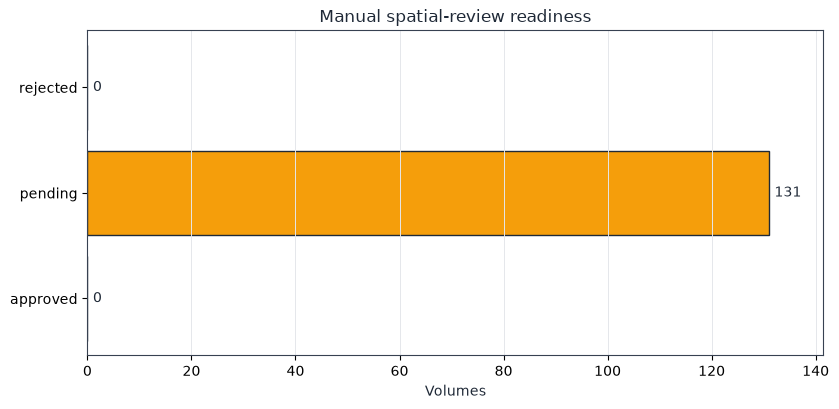

In [16]:
# Readiness composition visual.
status_colors = {"approved": "#2563eb", "pending": "#f59e0b", "rejected": "#9ca3af"}
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.barh(review_status.status, review_status.volumes, color=[status_colors[s] for s in review_status.status], edgecolor="#1f2937")
ax.bar_label(bars, labels=[str(value) for value in review_status.volumes], padding=4)
ax.set_xlim(0, EXPECTED_VOLUMES * 1.08)
ax.set_xlabel("Volumes")
ax.set_title("Manual spatial-review readiness")
ax.grid(axis="x", color="#e5e7eb", linewidth=0.7)
plt.tight_layout()
plt.show()


## 11. EDA tables and visualizations

These plots use the corrected manifest when available. In audit-only mode they use the current staging manifest and remain explicitly provisional.

In [17]:
if eda_manifest is not None:
    analysis_manifest = eda_manifest.copy()
    organ_column = "organ_pixels"
    tumor_column = "tumor_pixels"
    tumor_present_column = "tumor_present"
else:
    analysis_manifest = current_manifest.copy()
    organ_column = "organ_pixels_256"
    tumor_column = "tumor_pixels_256"
    tumor_present_column = "tumor_present_256"
    analysis_manifest["split"] = analysis_manifest.volume_id.map(assign_split)

volume_summary = analysis_manifest.groupby(["volume_id", "split"]).agg(
    slices=("slice_index", "count"),
    tumor_positive_slices=(tumor_present_column, "sum"),
    organ_pixels=(organ_column, "sum"),
    tumor_pixels=(tumor_column, "sum"),
).reset_index()
volume_summary["tumor_positive_rate"] = volume_summary.tumor_positive_slices / volume_summary.slices
volume_summary.to_csv(AUDIT_OUTPUT_DIR / "eda_volume_summary.csv", index=False)

split_summary = analysis_manifest.groupby("split").agg(
    volumes=("volume_id", "nunique"),
    slices=("slice_index", "count"),
    tumor_positive_slices=(tumor_present_column, "sum"),
    organ_pixels=(organ_column, "sum"),
    tumor_pixels=(tumor_column, "sum"),
).reset_index()
split_summary["positive_slice_rate"] = split_summary.tumor_positive_slices / split_summary.slices
split_summary.to_csv(AUDIT_OUTPUT_DIR / "eda_split_summary.csv", index=False)

display(split_summary)


,split,volumes,slices,tumor_positive_slices,organ_pixels,tumor_pixels,positive_slice_rate
0,test,14,7286,1197,12268740,1366941,0.164288
1,train,104,40667,4930,63862581,2589463,0.121229
2,val,13,10685,1042,11675392,659487,0.097520


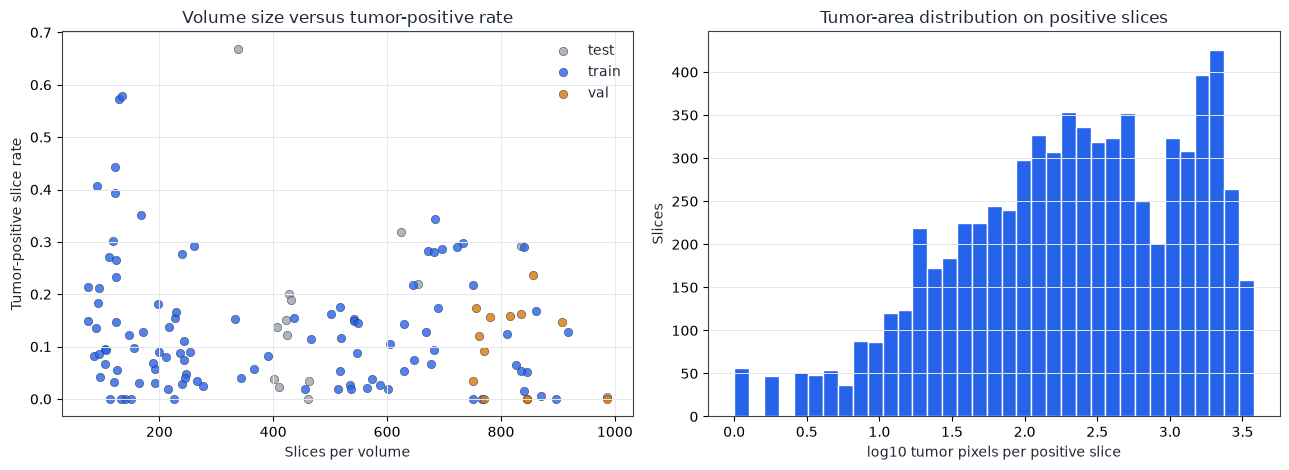

In [18]:
split_palette = {"train": "#2563eb", "val": "#d97706", "test": "#9ca3af"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for split_name, group in volume_summary.groupby("split"):
    axes[0].scatter(
        group.slices,
        group.tumor_positive_rate,
        label=split_name,
        color=split_palette[split_name],
        edgecolor="#1f2937",
        linewidth=0.4,
        alpha=0.8,
    )
axes[0].set_xlabel("Slices per volume")
axes[0].set_ylabel("Tumor-positive slice rate")
axes[0].set_title("Volume size versus tumor-positive rate")
axes[0].grid(color="#e5e7eb", linewidth=0.7)
axes[0].legend(frameon=False)

positive_tumor_pixels = analysis_manifest.loc[analysis_manifest[tumor_column] > 0, tumor_column]
axes[1].hist(np.log10(positive_tumor_pixels), bins=35, color="#2563eb", edgecolor="white")
axes[1].set_xlabel("log10 tumor pixels per positive slice")
axes[1].set_ylabel("Slices")
axes[1].set_title("Tumor-area distribution on positive slices")
axes[1].grid(axis="y", color="#e5e7eb", linewidth=0.7)

plt.tight_layout()
plt.show()


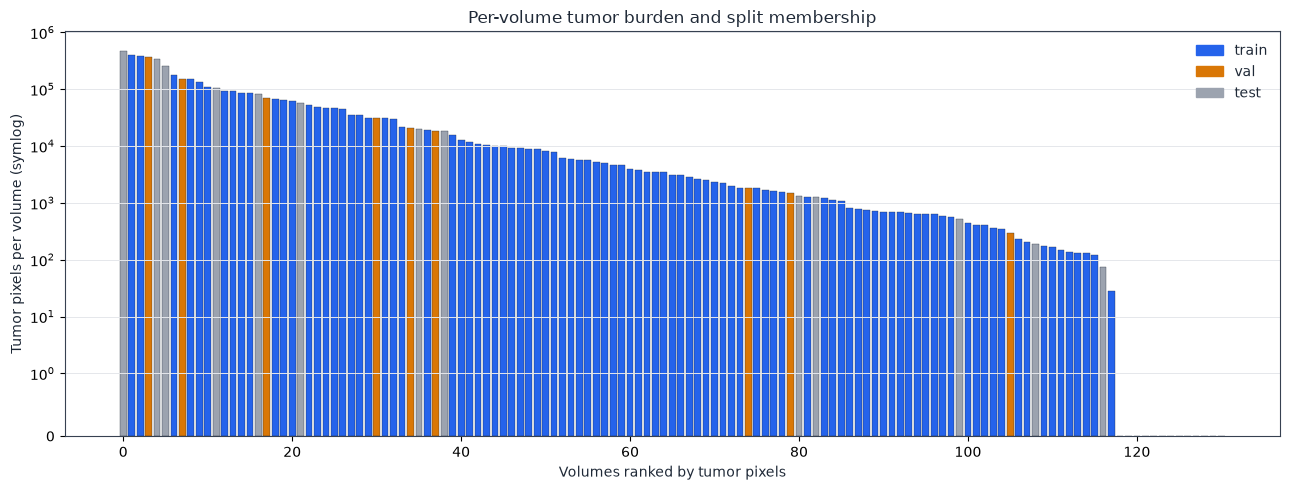

In [19]:
# Ordered per-volume tumor burden.
ordered_volume_summary = volume_summary.sort_values("tumor_pixels", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 5.0))
colors = [split_palette[split_name] for split_name in ordered_volume_summary.split]
ax.bar(range(len(ordered_volume_summary)), ordered_volume_summary.tumor_pixels, color=colors, edgecolor="#1f2937", linewidth=0.25)
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("Volumes ranked by tumor pixels")
ax.set_ylabel("Tumor pixels per volume (symlog)")
ax.set_title("Per-volume tumor burden and split membership")
ax.grid(axis="y", color="#e5e7eb", linewidth=0.7)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=split_palette[name]) for name in ["train", "val", "test"]]
ax.legend(legend_handles, ["train", "val", "test"], frameon=False)
plt.tight_layout()
plt.show()


## 12. Final readiness decision

The dataset is spatial-EDA ready only when the corrected build passes every automatic gate and all 131 volumes are manually approved. A failed gate produces a no-go decision; it does not delete or alter evidence.

,run_id,audit_output_dir,corrected_build_dir,source_key_count,source_volume_count,nifti_complete_pairs,nifti_shape_matches,nifti_affine_matches,automatic_build_gates_pass,manually_approved_volumes,manually_rejected_volumes,nonspatial_eda_ready,spatial_eda_ready,training_ready,next_required_action
0,20260724_211625,D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\P...,None,58638,131,131,131,79,False,0,0,False,False,False,Review/correct all orientation figures and com...


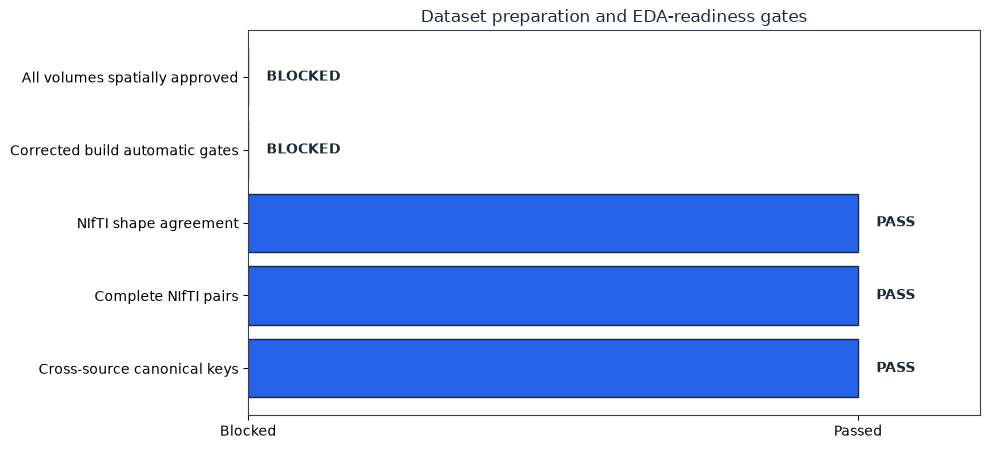

SPATIAL_EDA_READY = False
TRAINING_READY = False  # training requires a later overfit and loader-validation gate


In [20]:
automatic_pass = bool(len(gate_table) and gate_table.passed.all())
manual_approved_count = int(review_status.loc[review_status.status == "approved", "volumes"].iloc[0])
manual_rejected_count = int(review_status.loc[review_status.status == "rejected", "volumes"].iloc[0])

readiness = {
    "run_id": RUN_ID,
    "audit_output_dir": str(AUDIT_OUTPUT_DIR),
    "corrected_build_dir": str(CORRECTED_BUILD_DIR) if corrected_manifest is not None else None,
    "source_key_count": int(len(crosswalk)),
    "source_volume_count": int(crosswalk.volume_id.nunique()),
    "nifti_complete_pairs": int(volume_registry.pair_complete.sum()),
    "nifti_shape_matches": int(volume_registry.shape_match.fillna(False).sum()),
    "nifti_affine_matches": int(volume_registry.affine_match.fillna(False).sum()),
    "automatic_build_gates_pass": automatic_pass,
    "manually_approved_volumes": manual_approved_count,
    "manually_rejected_volumes": manual_rejected_count,
    "nonspatial_eda_ready": corrected_manifest is not None and automatic_pass,
    "spatial_eda_ready": corrected_manifest is not None and automatic_pass and manual_approved_count == EXPECTED_VOLUMES and manual_rejected_count == 0,
    "training_ready": False,
    "next_required_action": "Review/correct all orientation figures and complete the 131-volume spatial approval before spatial EDA or training.",
}
write_json(readiness, AUDIT_OUTPUT_DIR / "dataset_readiness.json")

readiness_table = pd.DataFrame([
    {"gate": "Cross-source canonical keys", "passed": len(crosswalk) == EXPECTED_SLICES},
    {"gate": "Complete NIfTI pairs", "passed": int(volume_registry.pair_complete.sum()) == EXPECTED_VOLUMES},
    {"gate": "NIfTI shape agreement", "passed": int(volume_registry.shape_match.fillna(False).sum()) == EXPECTED_VOLUMES},
    {"gate": "Corrected build automatic gates", "passed": automatic_pass},
    {"gate": "All volumes spatially approved", "passed": manual_approved_count == EXPECTED_VOLUMES and manual_rejected_count == 0},
])
display(pd.DataFrame([readiness]))

fig, ax = plt.subplots(figsize=(10, 4.6))
colors = ["#2563eb" if passed else "#f59e0b" for passed in readiness_table.passed]
bars = ax.barh(readiness_table.gate, readiness_table.passed.astype(int), color=colors, edgecolor="#1f2937")
ax.set_xlim(0, 1.2)
ax.set_xticks([0, 1], labels=["Blocked", "Passed"])
ax.set_title("Dataset preparation and EDA-readiness gates")
for bar, passed in zip(bars, readiness_table.passed):
    ax.text(1.03 if passed else 0.03, bar.get_y() + bar.get_height() / 2, "PASS" if passed else "BLOCKED", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("SPATIAL_EDA_READY =", readiness["spatial_eda_ready"])
print("TRAINING_READY = False  # training requires a later overfit and loader-validation gate")


## Next steps

1. Run once with `BUILD_CORRECTED=False`.
2. Review `orientation_reviews/` and `orientation_diagnostics.csv`.
3. Expand `ORIENTATION_REVIEW_VOLUMES` to all 131 volumes if any transform block remains uncertain.
4. Approve the transform map only after the overlays are convincing.
5. Enable the isolated corrected build.
6. Review the corrected build across all volumes and populate the manual approval sets.
7. Regenerate the EDA-ready manifests and confirm `SPATIAL_EDA_READY=True`.
8. Only then create the dedicated EDA notebook and later run the 16-slice training overfit gate.

Do not promote the dataset or start model training merely because file-count gates pass.